# HAI822I — Visualisation des benchmarks ParcCapteurs

**Structures comparées :** `LinkedList<Capteur>` vs `HashMap<Integer, Capteur>`  
**Opérations :** ajout, recherche, suppression, inventaire, comptage  
**Scénarios :** S1-Equilibre, S2-LectureIntensive, S3-EcritureIntensive, S4-InventaireIntensif, S5-ComptageIntensif  

---

## Comment brancher vos données Java

Le programme Java exporte deux formats via `System.out` :

### Option A — CSV (recommandée)
```bash
# Depuis le répertoire bin/ :
java -cp bin app.MainParcCapteurs 2>/dev/null | grep -A9999 'CSV EXPORT' | tail -n +2 > results.csv
```
Puis dans la **Cellule 2** ci-dessous, remplacez `LOAD_MODE = 'sample'` par `LOAD_MODE = 'csv'` et ajustez `CSV_PATH`.

### Option B — JSON
```bash
java -cp bin app.MainParcCapteurs 2>/dev/null | grep -A99999 'JSON EXPORT' | tail -n +2 > results.json
```
Puis dans la **Cellule 2**, utilisez `LOAD_MODE = 'json'`.

### Colonnes attendues dans le CSV
```
structure, scenario, taille, ajout_ms, recherche_ms, suppression_ms, inventaire_ms, comptage_ms, total_ms, memoire_ko
```

In [1]:
# ── Cellule 1 : Imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {'LinkedList': '#E05C5C', 'HashMap': '#4A90D9'}
print('Imports OK')

Imports OK


In [8]:
# ── Cellule 2 : Chargement des données ──────────────────────────────────────
#
# LOAD_MODE = 'sample'  → données simulées (pour tester sans Java)
# LOAD_MODE = 'csv'     → lire results.csv produit par Java
# LOAD_MODE = 'json'    → lire results.json produit par Java

LOAD_MODE = 'sample'   # Reverted to sample mode as 'results.csv' is still not found
CSV_PATH  = 'results.csv'
JSON_PATH = 'results.json'

# ─────────────────────────────────────────────────────────────────────────────

SCENARIOS = [
    'S1-Equilibre',
    'S2-LectureIntensive',
    'S3-EcritureIntensive',
    'S4-InventaireIntensif',
    'S5-ComptageIntensif',
]
TAILLES = [100, 500, 1000, 2000, 5000, 10000]
STRUCTURES = ['LinkedList', 'HashMap']
OPS = ['ajout_ms', 'recherche_ms', 'suppression_ms', 'inventaire_ms', 'comptage_ms']
OPS_LABELS = ['Ajout', 'Recherche', 'Suppression', 'Inventaire', 'Comptage']

# ── Générateur de données simulées ─────────────────────────────────────────
def make_sample_data() -> pd.DataFrame:
    """
    Simule des résultats plausibles pour LinkedList vs HashMap :
    - LinkedList : recherche/suppression en O(n) => croissance linéaire
    - HashMap    : recherche/suppression en O(1) => quasi-constant
    """
    rng = np.random.default_rng(42)
    rows = []
    for sc in SCENARIOS:
        for n in TAILLES:
            for struct in STRUCTURES:
                scale = n / 1000
                if struct == 'LinkedList':
                    ajout       = 0.05 * scale + rng.normal(0, 0.005)
                    recherche   = 0.80 * scale + rng.normal(0, 0.05)
                    suppression = 0.75 * scale + rng.normal(0, 0.05)
                    inventaire  = 0.10 * scale + rng.normal(0, 0.01)
                    comptage    = 0.12 * scale + rng.normal(0, 0.01)
                else:  # HashMap
                    ajout       = 0.04 + 0.002*scale + rng.normal(0, 0.003)
                    recherche   = 0.02 + 0.001*scale + rng.normal(0, 0.002)
                    suppression = 0.02 + 0.001*scale + rng.normal(0, 0.002)
                    inventaire  = 0.08 * scale + rng.normal(0, 0.01)
                    comptage    = 0.09 * scale + rng.normal(0, 0.01)
                vals = [max(0.001, v) for v in [ajout, recherche, suppression, inventaire, comptage]]
                total = sum(vals)
                # mémoire : HashMap un peu plus gourmand
                mem = n * (0.45 if struct == 'HashMap' else 0.30) + rng.normal(0, 2)
                rows.append(dict(
                    structure=struct, scenario=sc, taille=n,
                    ajout_ms=vals[0], recherche_ms=vals[1], suppression_ms=vals[2],
                    inventaire_ms=vals[3], comptage_ms=vals[4],
                    total_ms=total, memoire_ko=max(0, mem)
                ))
    return pd.DataFrame(rows)


if LOAD_MODE == 'csv':
    df = pd.read_csv(CSV_PATH)
    print(f'CSV chargé : {len(df)} lignes depuis {CSV_PATH}')
elif LOAD_MODE == 'json':
    with open(JSON_PATH) as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    print(f'JSON chargé : {len(df)} lignes depuis {JSON_PATH}')
else:
    df = make_sample_data()
    print(f'Données simulées générées : {len(df)} lignes (LOAD_MODE="sample")')

print(df.head())

Données simulées générées : 60 lignes (LOAD_MODE="sample")
    structure      scenario  taille  ajout_ms  recherche_ms  suppression_ms  \
0  LinkedList  S1-Equilibre     100  0.006524      0.028001        0.112523   
1     HashMap  S1-Equilibre     100  0.040584      0.019468        0.020066   
2  LinkedList  S1-Equilibre     500  0.025330      0.456362        0.398375   
3     HashMap  S1-Equilibre     500  0.043635      0.020400        0.020130   
4  LinkedList  S1-Equilibre    1000  0.047858      0.782393        0.776615   

   inventaire_ms  comptage_ms  total_ms  memoire_ko  
0       0.019406     0.001000  0.167453   27.395641  
1       0.001000     0.017794  0.098911   46.555584  
2       0.041407     0.063688  0.985162  148.082235  
3       0.033191     0.057225  0.174582  224.690941  
4       0.103654     0.124127  1.834649  300.861642  


---
## Graphique 1 — Temps total en fonction de la taille (par scénario)

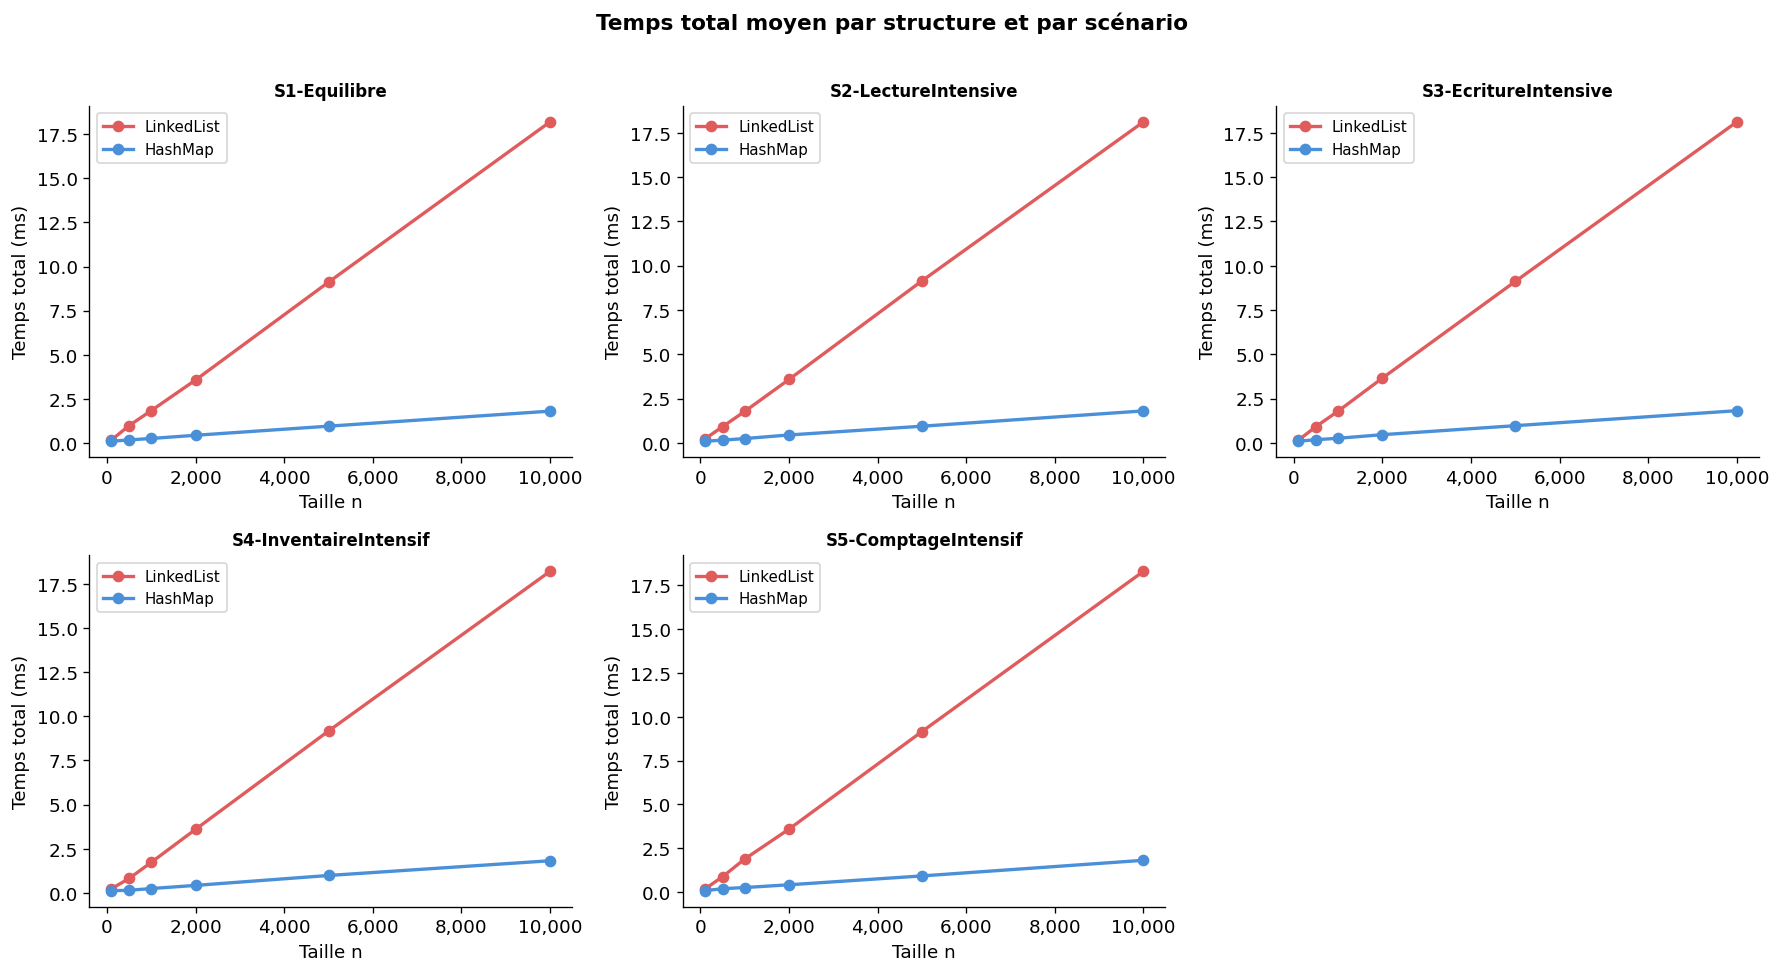

Sauvegardé : g1_total_par_scenario.png


In [9]:
# ── Graphique 1 : total_ms vs taille, un subplot par scénario ───────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.flatten()

for i, sc in enumerate(SCENARIOS):
    ax = axes[i]
    sub = df[df['scenario'] == sc]
    for struct in STRUCTURES:
        s = sub[sub['structure'] == struct].sort_values('taille')
        ax.plot(s['taille'], s['total_ms'],
                marker='o', linewidth=2, color=COLORS[struct], label=struct)
    ax.set_title(sc, fontsize=10, fontweight='bold')
    ax.set_xlabel('Taille n')
    ax.set_ylabel('Temps total (ms)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[-1].set_visible(False)   # 5 scénarios → 6e case vide
fig.suptitle('Temps total moyen par structure et par scénario', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('g1_total_par_scenario.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g1_total_par_scenario.png')

---
## Graphique 2 — Détail par opération (scénario équilibré S1)

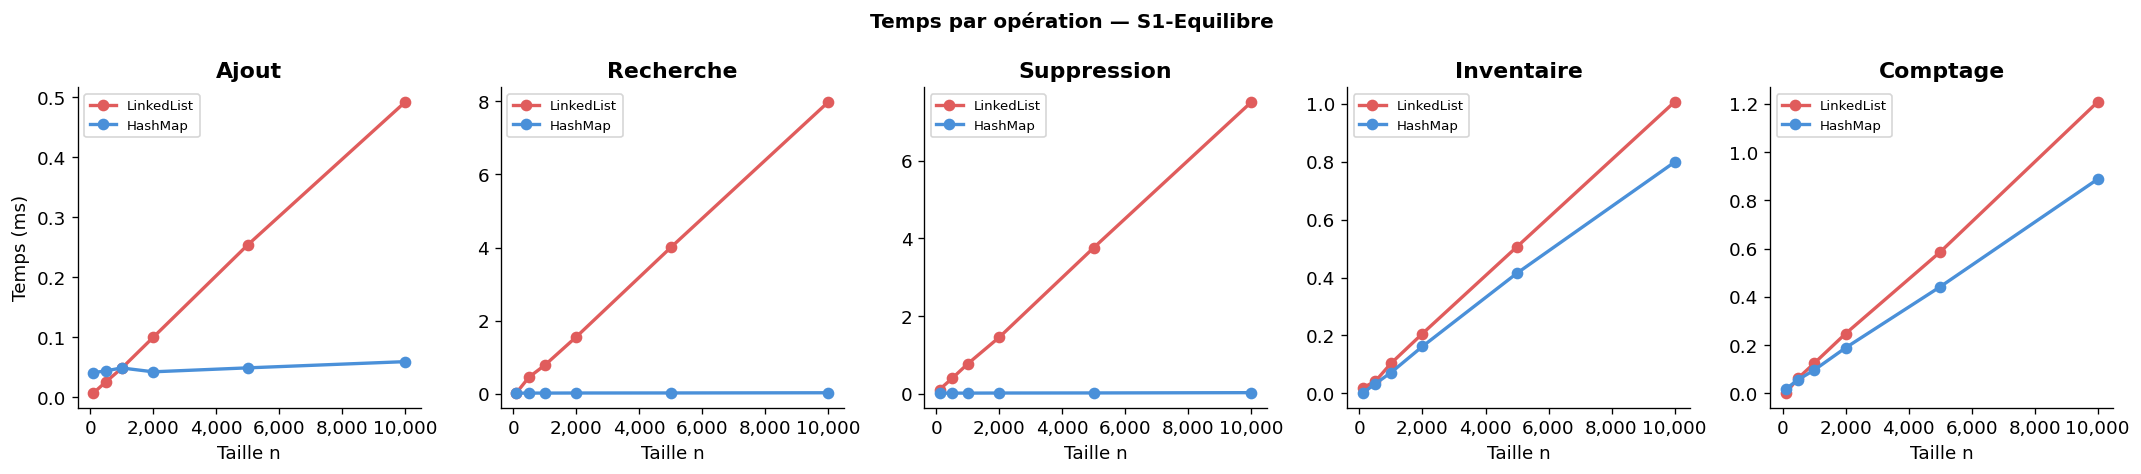

Sauvegardé : g2_ops_scenario_equilibre.png


In [10]:
# ── Graphique 2 : temps de chaque opération — scénario S1 ───────────────────
TARGET_SCENARIO = 'S1-Equilibre'   # ← changez si nécessaire

sub = df[df['scenario'] == TARGET_SCENARIO]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

for j, (col, label) in enumerate(zip(OPS, OPS_LABELS)):
    ax = axes[j]
    for struct in STRUCTURES:
        s = sub[sub['structure'] == struct].sort_values('taille')
        ax.plot(s['taille'], s[col], marker='o', linewidth=2,
                color=COLORS[struct], label=struct)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Taille n')
    if j == 0:
        ax.set_ylabel('Temps (ms)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle(f'Temps par opération — {TARGET_SCENARIO}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('g2_ops_scenario_equilibre.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g2_ops_scenario_equilibre.png')

---
## Graphique 3 — Comparaison des scénarios à taille fixe (barres groupées)

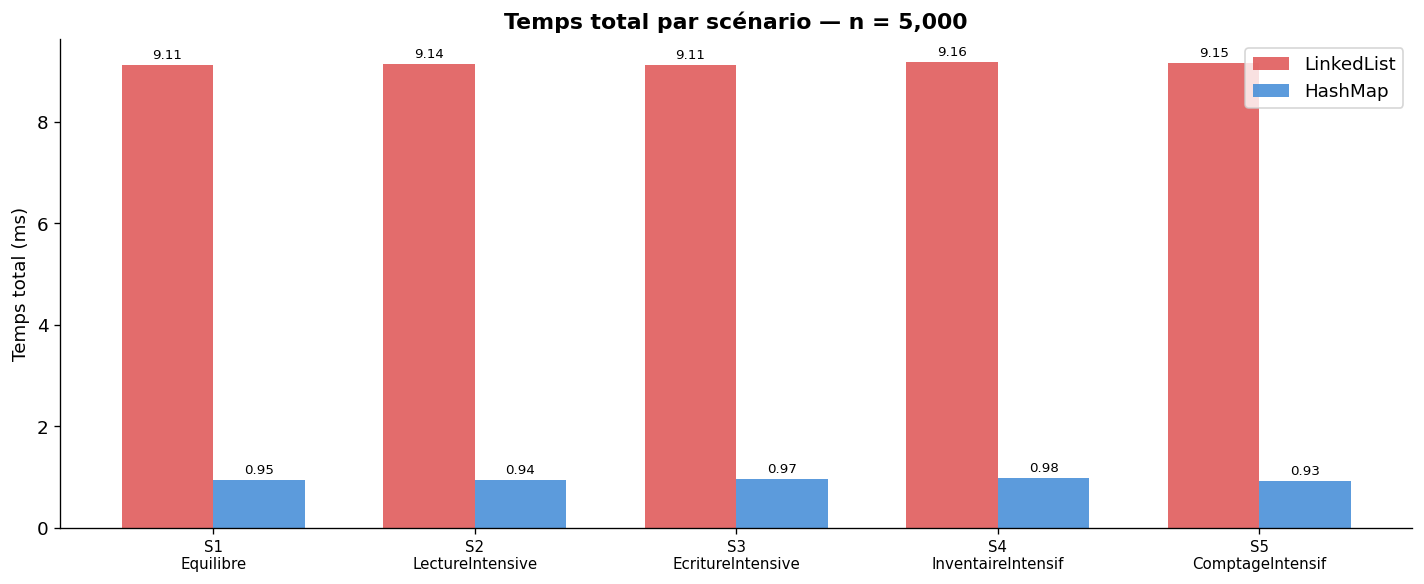

Sauvegardé : g3_barres_scenarios.png


In [11]:
# ── Graphique 3 : barres groupées scénarios × structures pour une taille fixe
TARGET_TAILLE = 5000   # ← changez selon vos tailles

sub = df[df['taille'] == TARGET_TAILLE]
pivot = sub.pivot(index='scenario', columns='structure', values='total_ms').reindex(SCENARIOS)

x = np.arange(len(SCENARIOS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_ll = ax.bar(x - width/2, pivot['LinkedList'], width,
                 color=COLORS['LinkedList'], label='LinkedList', alpha=0.9)
bars_hm = ax.bar(x + width/2, pivot['HashMap'],    width,
                 color=COLORS['HashMap'],    label='HashMap',    alpha=0.9)

ax.bar_label(bars_ll, fmt='%.2f', fontsize=8, padding=2)
ax.bar_label(bars_hm, fmt='%.2f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels([s.replace('-', '\n') for s in SCENARIOS], fontsize=9)
ax.set_ylabel('Temps total (ms)')
ax.set_title(f'Temps total par scénario — n = {TARGET_TAILLE:,}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('g3_barres_scenarios.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g3_barres_scenarios.png')

---
## Graphique 4 — Rapport de performance LinkedList / HashMap

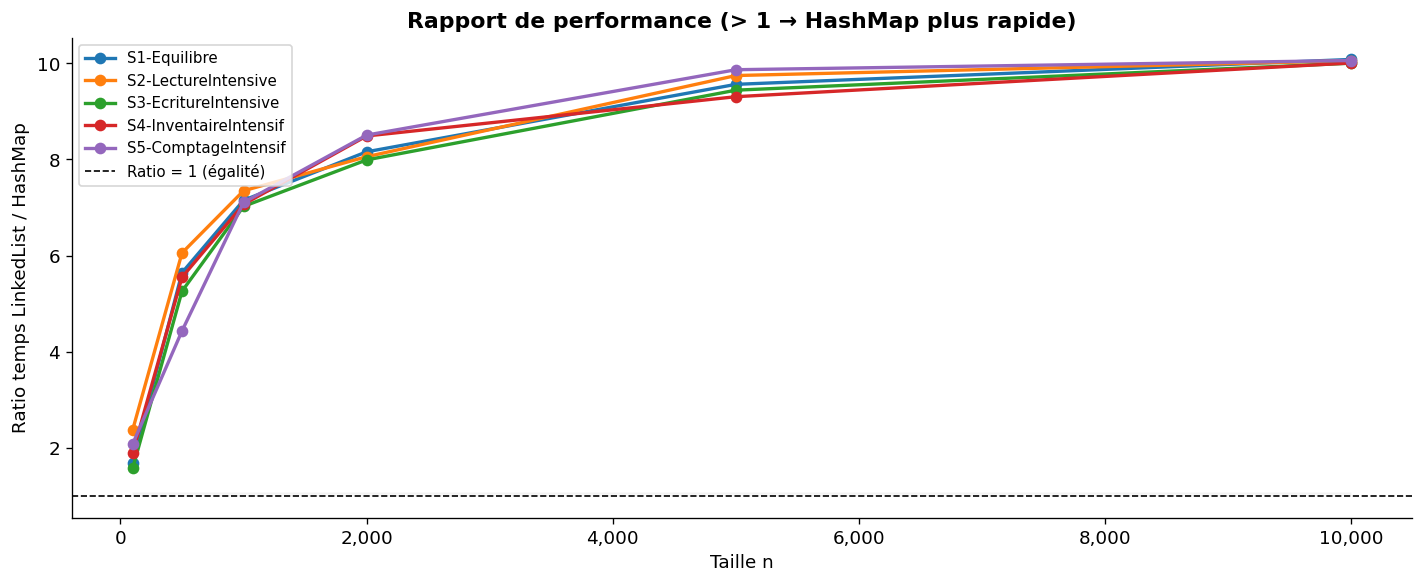

Sauvegardé : g4_ratio_performance.png


In [12]:
# ── Graphique 4 : ratio LL/HM (> 1 = HashMap plus rapide) ──────────────────
ll = df[df['structure']=='LinkedList'][['scenario','taille','total_ms']].rename(columns={'total_ms':'ll'})
hm = df[df['structure']=='HashMap'  ][['scenario','taille','total_ms']].rename(columns={'total_ms':'hm'})
ratio_df = ll.merge(hm, on=['scenario','taille'])
ratio_df['ratio'] = ratio_df['ll'] / ratio_df['hm']  # >1 → HashMap gagne

fig, ax = plt.subplots(figsize=(12, 5))

for sc in SCENARIOS:
    s = ratio_df[ratio_df['scenario'] == sc].sort_values('taille')
    ax.plot(s['taille'], s['ratio'], marker='o', linewidth=2, label=sc)

ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Ratio = 1 (égalité)')
ax.fill_between(TAILLES, 1, 1.05, alpha=0.05, color='grey')  # zone neutre
ax.set_xlabel('Taille n')
ax.set_ylabel('Ratio temps LinkedList / HashMap')
ax.set_title('Rapport de performance (> 1 → HashMap plus rapide)', fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('g4_ratio_performance.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g4_ratio_performance.png')

---
## Graphique 5 — Occupation mémoire

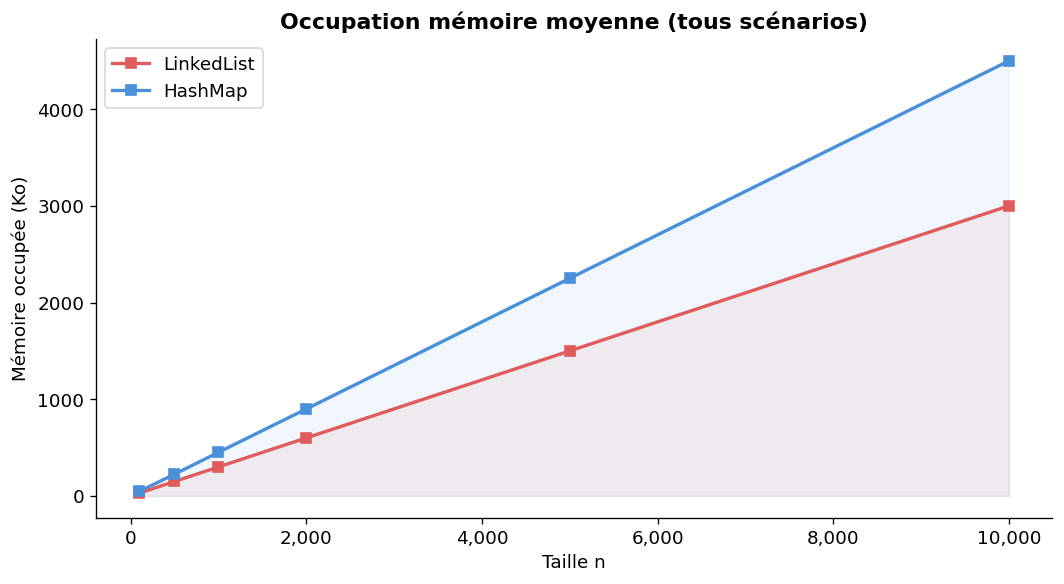

Sauvegardé : g5_memoire.png


In [13]:
# ── Graphique 5 : mémoire (Ko) vs taille ────────────────────────────────────
# Moyenne sur tous les scénarios pour une même taille+structure
mem_df = df.groupby(['structure','taille'])['memoire_ko'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for struct in STRUCTURES:
    s = mem_df[mem_df['structure'] == struct].sort_values('taille')
    ax.plot(s['taille'], s['memoire_ko'], marker='s', linewidth=2,
            color=COLORS[struct], label=struct)
    ax.fill_between(s['taille'], s['memoire_ko'], alpha=0.08, color=COLORS[struct])

ax.set_xlabel('Taille n')
ax.set_ylabel('Mémoire occupée (Ko)')
ax.set_title('Occupation mémoire moyenne (tous scénarios)', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('g5_memoire.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g5_memoire.png')

---
## Graphique 6 — Heatmap des temps par opération et scénario (n fixe)

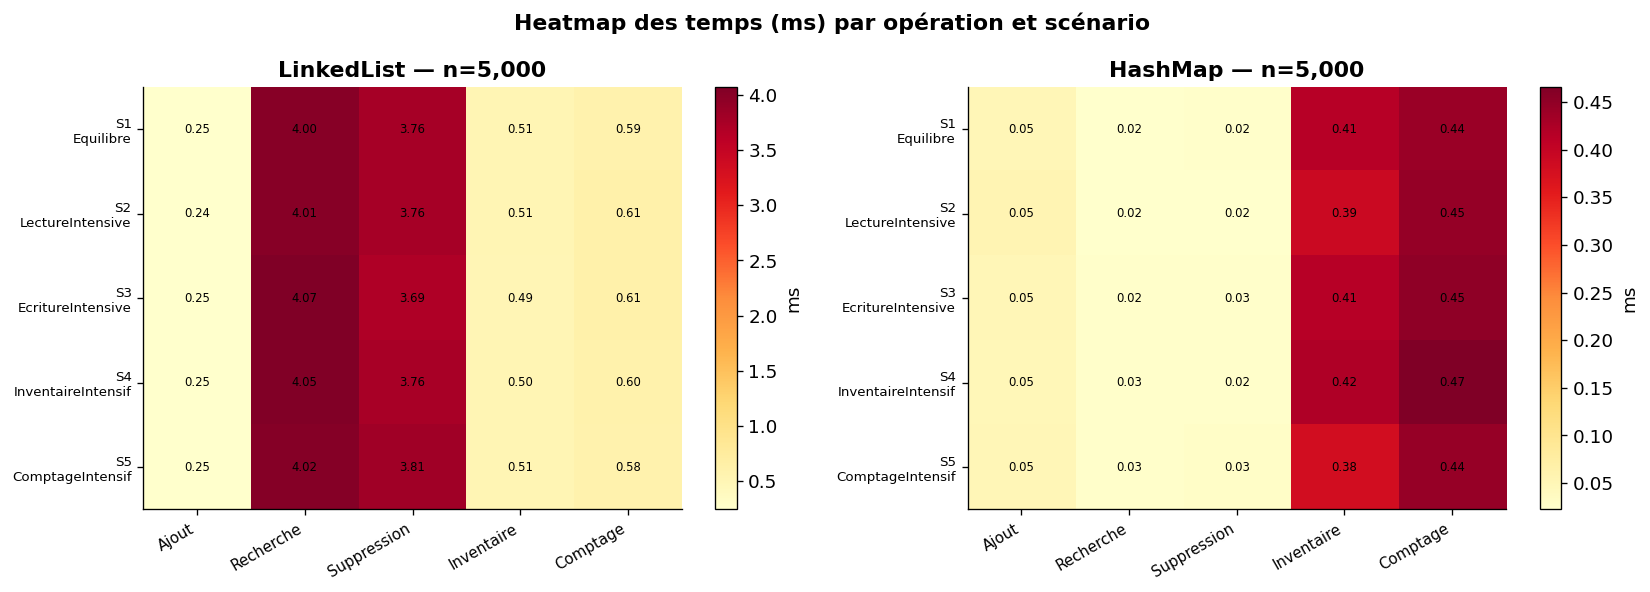

Sauvegardé : g6_heatmap.png


In [14]:
# ── Graphique 6 : heatmap opération × scénario ──────────────────────────────
TARGET_TAILLE_HEAT = 5000

sub = df[df['taille'] == TARGET_TAILLE_HEAT]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, struct in zip(axes, STRUCTURES):
    s = sub[sub['structure'] == struct].set_index('scenario')[OPS]
    s.columns = OPS_LABELS
    s = s.reindex(SCENARIOS)

    im = ax.imshow(s.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(OPS_LABELS)))
    ax.set_xticklabels(OPS_LABELS, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(SCENARIOS)))
    ax.set_yticklabels([sc.replace('-','\n') for sc in SCENARIOS], fontsize=8)
    ax.set_title(f'{struct} — n={TARGET_TAILLE_HEAT:,}', fontweight='bold')
    plt.colorbar(im, ax=ax, label='ms')

    for i in range(s.shape[0]):
        for j in range(s.shape[1]):
            ax.text(j, i, f'{s.values[i,j]:.2f}',
                    ha='center', va='center', fontsize=7, color='black')

fig.suptitle('Heatmap des temps (ms) par opération et scénario', fontweight='bold')
plt.tight_layout()
plt.savefig('g6_heatmap.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g6_heatmap.png')

---
## Graphique 7 — Scénario mixte « radar » / pile 100 % (structure gagnante)

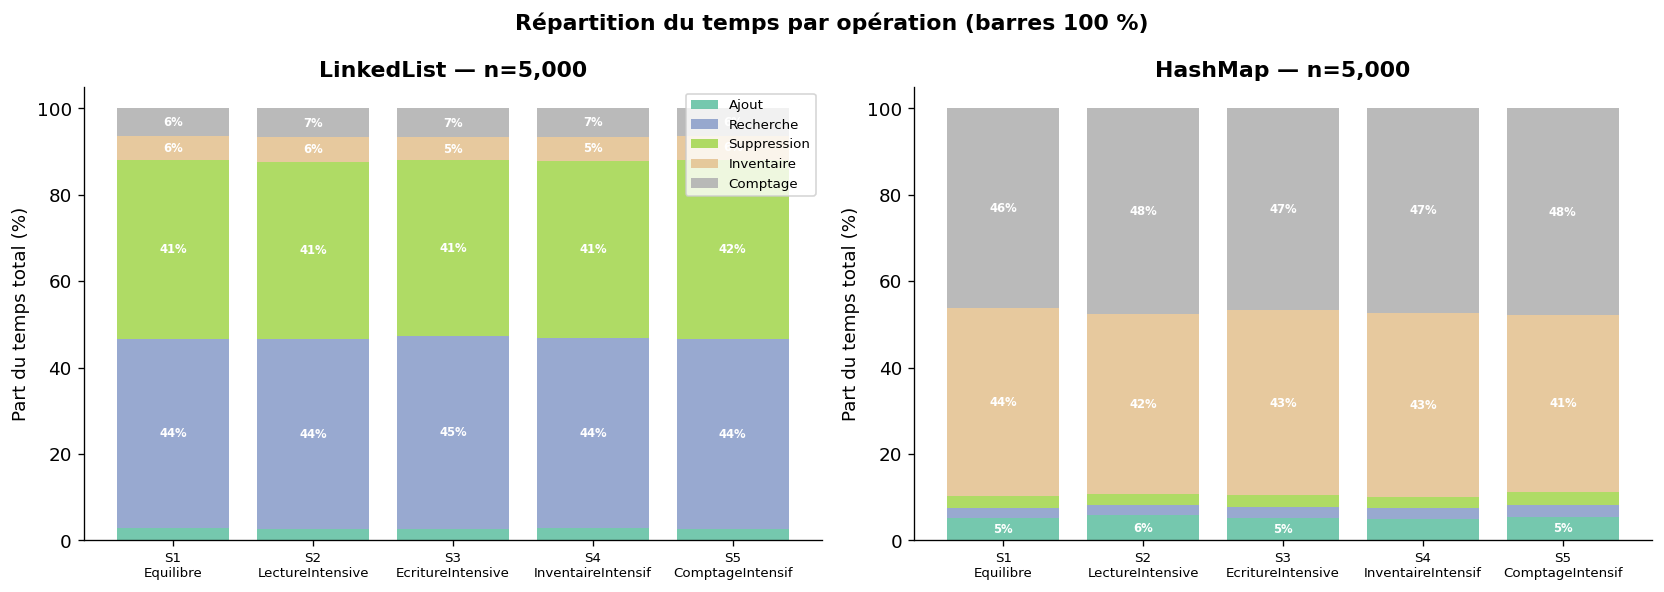

Sauvegardé : g7_repartition_operations.png


In [15]:
# ── Graphique 7 : barres empilées 100 % — répartition des opérations ────────
# Montre d'où vient le temps total dans chaque scénario pour n=5000
TARGET_TAILLE_STACK = 5000

sub = df[df['taille'] == TARGET_TAILLE_STACK]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = plt.cm.Set2(np.linspace(0, 1, len(OPS)))

for ax, struct in zip(axes, STRUCTURES):
    s = sub[sub['structure'] == struct].set_index('scenario')[OPS].reindex(SCENARIOS)
    totals = s.sum(axis=1)
    s_pct = s.div(totals, axis=0) * 100

    bottom = np.zeros(len(SCENARIOS))
    for k, (col, label) in enumerate(zip(OPS, OPS_LABELS)):
        vals = s_pct[col].values
        ax.bar(range(len(SCENARIOS)), vals, bottom=bottom,
               color=palette[k], label=label, alpha=0.9)
        # Ajouter le % si assez large
        for idx, (v, b) in enumerate(zip(vals, bottom)):
            if v > 5:
                ax.text(idx, b + v/2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=7, color='white', fontweight='bold')
        bottom += vals

    ax.set_xticks(range(len(SCENARIOS)))
    ax.set_xticklabels([s.replace('-','\n') for s in SCENARIOS], fontsize=8)
    ax.set_ylabel('Part du temps total (%)')
    ax.set_ylim(0, 105)
    ax.set_title(f'{struct} — n={TARGET_TAILLE_STACK:,}', fontweight='bold')
    if ax == axes[0]:
        ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Répartition du temps par opération (barres 100 %)', fontweight='bold')
plt.tight_layout()
plt.savefig('g7_repartition_operations.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g7_repartition_operations.png')

---
## Graphique 8 — Courbes log-log (mise en évidence des complexités)

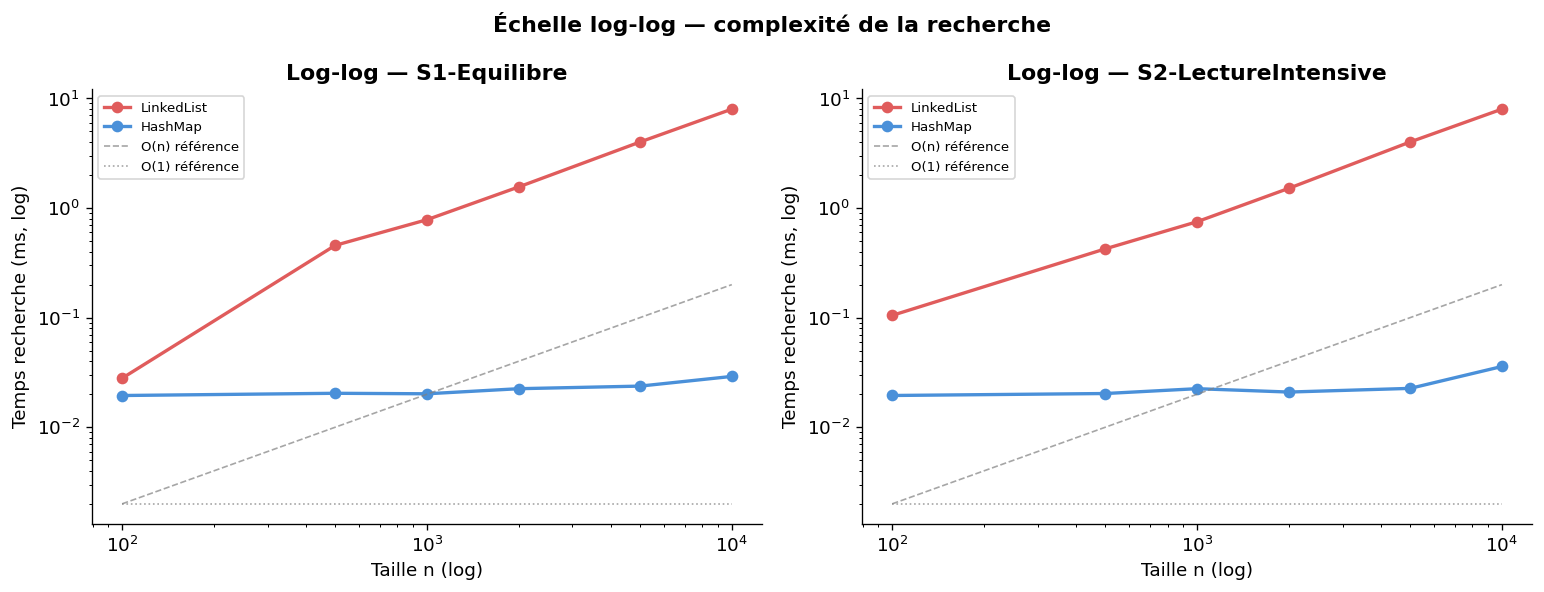

Sauvegardé : g8_loglog.png


In [16]:
# ── Graphique 8 : échelle log-log pour visualiser O(1) vs O(n) ──────────────
# On utilise l'opération de recherche (la plus discriminante)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sc in [( axes[0], 'S1-Equilibre'), (axes[1], 'S2-LectureIntensive')]:
    sub = df[df['scenario'] == sc]
    for struct in STRUCTURES:
        s = sub[sub['structure'] == struct].sort_values('taille')
        ax.loglog(s['taille'], s['recherche_ms'],
                  marker='o', linewidth=2, color=COLORS[struct], label=struct)

    # Référence théorique O(n) et O(1)
    n_ref = np.array(TAILLES, dtype=float)
    ax.loglog(n_ref, n_ref / n_ref[0] * 0.002, '--', color='gray',
              linewidth=1, alpha=0.7, label='O(n) référence')
    ax.loglog(n_ref, np.ones_like(n_ref) * 0.002, ':', color='gray',
              linewidth=1, alpha=0.7, label='O(1) référence')

    ax.set_xlabel('Taille n (log)')
    ax.set_ylabel('Temps recherche (ms, log)')
    ax.set_title(f'Log-log — {sc}', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Échelle log-log — complexité de la recherche', fontweight='bold')
plt.tight_layout()
plt.savefig('g8_loglog.png', bbox_inches='tight')
plt.show()
print('Sauvegardé : g8_loglog.png')

---
## Tableau récapitulatif — Quelle structure gagne par scénario ?

In [17]:
# ── Tableau récapitulatif ────────────────────────────────────────────────────
summary_rows = []
for sc in SCENARIOS:
    for taille in TAILLES:
        sub = df[(df['scenario'] == sc) & (df['taille'] == taille)]
        if sub.empty:
            continue
        ll_t = sub[sub['structure']=='LinkedList']['total_ms'].values[0]
        hm_t = sub[sub['structure']=='HashMap'   ]['total_ms'].values[0]
        winner = 'HashMap' if hm_t < ll_t else 'LinkedList'
        gain_pct = abs(ll_t - hm_t) / max(ll_t, hm_t) * 100
        summary_rows.append(dict(scenario=sc, taille=taille,
                                 LL_ms=round(ll_t,3), HM_ms=round(hm_t,3),
                                 winner=winner, gain_pct=round(gain_pct,1)))

summary = pd.DataFrame(summary_rows)

def color_winner(val):
    if val == 'HashMap':
        return 'background-color: #c8e6fa; color: #1a3d5c'
    return 'background-color: #fdd; color: #5c1a1a'

display(summary.style.applymap(color_winner, subset=['winner'])
               .format({'LL_ms': '{:.3f}', 'HM_ms': '{:.3f}', 'gain_pct': '{:.1f}%'})
               .set_caption('Structure gagnante par scénario et taille'))

summary.to_csv('recap_winner.csv', index=False)
print('Sauvegardé : recap_winner.csv')

/tmp/ipykernel_21334/4128947901.py:23: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(summary.style.applymap(color_winner, subset=['winner'])


,scenario,taille,LL_ms,HM_ms,winner,gain_pct
0,S1-Equilibre,100,0.167,0.099,HashMap,40.9%
1,S1-Equilibre,500,0.985,0.175,HashMap,82.3%
2,S1-Equilibre,1000,1.835,0.257,HashMap,86.0%
3,S1-Equilibre,2000,3.570,0.438,HashMap,87.7%
4,S1-Equilibre,5000,9.113,0.953,HashMap,89.5%
5,S1-Equilibre,10000,18.196,1.805,HashMap,90.1%
6,S2-LectureIntensive,100,0.213,0.089,HashMap,58.0%
7,S2-LectureIntensive,500,0.910,0.150,HashMap,83.5%
8,S2-LectureIntensive,1000,1.771,0.241,HashMap,86.4%
9,S2-LectureIntensive,2000,3.576,0.444,HashMap,87.6%


Sauvegardé : recap_winner.csv


---

## Aide-mémoire : intégrer les vraies données Java

### Extraction du CSV depuis le terminal
```bash
# Depuis le dossier racine du projet :
javac -d bin -sourcepath src src/app/MainParcCapteurs.java
java -cp bin app.MainParcCapteurs > full_output.txt

# Extraire uniquement la section CSV :
awk '/=== CSV EXPORT ===/,/=== JSON EXPORT ==/' full_output.txt \
    | grep -v '===' > results.csv

# Extraire uniquement la section JSON :
awk '/=== JSON EXPORT ===/,0' full_output.txt \
    | grep -v '===' > results.json
```

### Dans ce notebook
Modifier la **Cellule 2** :
```python
LOAD_MODE = 'csv'          # ou 'json'
CSV_PATH  = 'results.csv'  # chemin relatif ou absolu
```
Puis **Kernel → Restart & Run All**.

### Colonnes attendues
| Colonne | Type | Description |
|---|---|---|
| `structure` | str | `LinkedList` ou `HashMap` |
| `scenario` | str | e.g. `S1-Equilibre` |
| `taille` | int | nombre d'éléments |
| `ajout_ms` | float | temps moyen ajout (ms) |
| `recherche_ms` | float | temps moyen recherche (ms) |
| `suppression_ms` | float | temps moyen suppression (ms) |
| `inventaire_ms` | float | temps moyen inventaire (ms) |
| `comptage_ms` | float | temps moyen comptage (ms) |
| `total_ms` | float | somme des 5 temps |
| `memoire_ko` | float | mémoire utilisée (Ko) |